In [ ]:
#Gravitational Motion
#
#
#
#

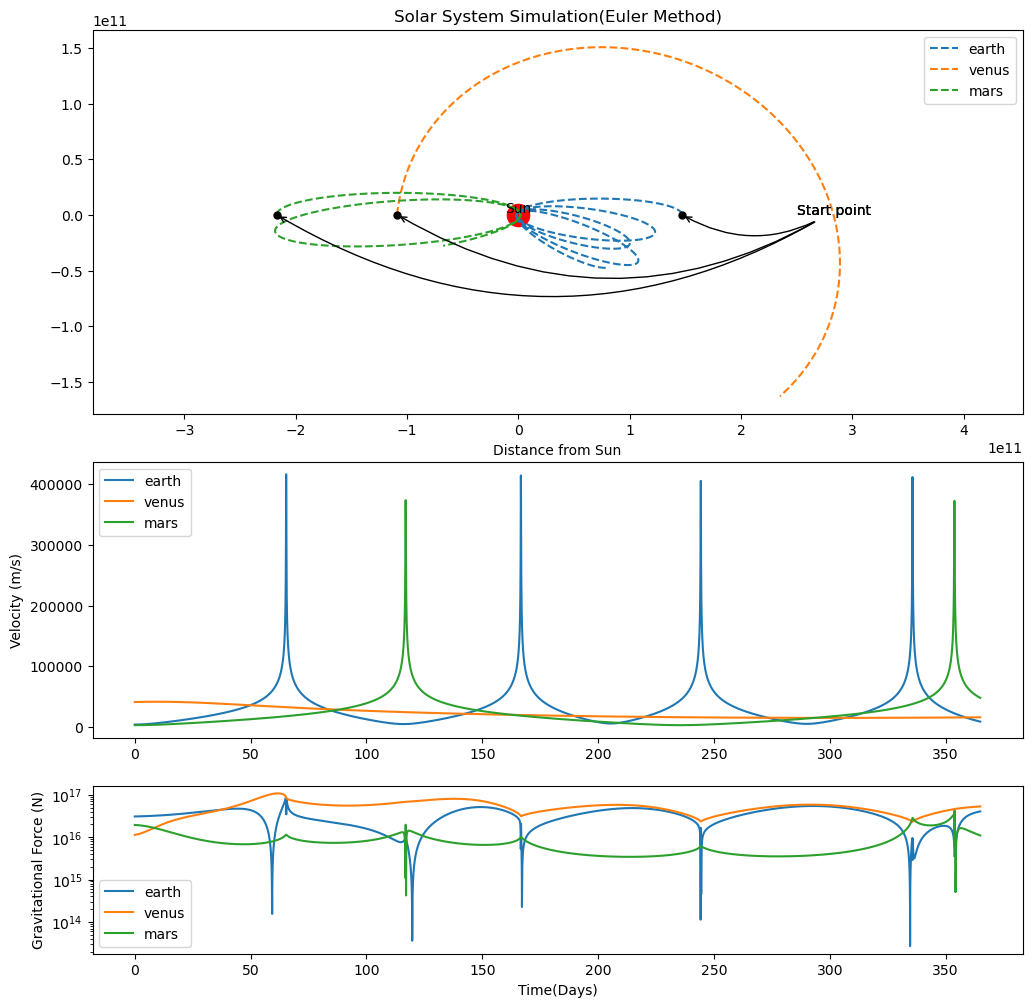

In [5]:
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np

class Planets:
    all_planets=[]
    fig=plt.figure(figsize=(12,12))
    grid=plt.GridSpec(9,4,hspace=0.8,wspace=0.2)
    main_ax=fig.add_subplot(grid[:4,:])
    velocity_ax=fig.add_subplot(grid[4:-2,:])
    force_ax=fig.add_subplot(grid[7:,:])

    main_ax.annotate("Sun",xy=(0,2.0e9),ha="center")
    main_ax.plot(0,0,"or",markersize=16)
    main_ax.axis("equal")
    main_ax.set_title("Solar System Simulation(Euler Method)")
    main_ax.set_xlabel("Distance from Sun")
    velocity_ax.set_ylabel("Velocity (m/s)")
    force_ax.set_ylabel("Gravitational Force (N)")
    force_ax.set_xlabel("Time(Days)")
    dt=3600
    grav_const=6.67e-11
    mass_sun=1.9e30
    def __init__(self,name,mass,x,y,vx,vy):
        self.name=name
        self.mass=mass
        self.x=x
        self.y=y
        self.vx=vx
        self.vy=vy
        self.x_position=[]
        self.y_position=[]
        self.velocity=[]
        self.force=[]
        
        Planets.all_planets.append(self)
    def trajectory(self):
            total_ax=0
            total_ay=0
            for other in Planets.all_planets:
                if other==self:
                    continue
                else:
                    dist_x=self.x-other.x
                    dist_y=self.y-other.y
                    dist=np.sqrt(dist_x**2+dist_y**2)
                    
                    a_other=-self.grav_const*other.mass/(dist**2)
                    total_ax+=a_other*dist_x/dist
                    total_ay+=a_other*dist_y/dist
            #about sun, manually
            self.r_sun=np.sqrt(self.x**2+self.y**2)
            grav_force_sun=-self.grav_const*self.mass*self.mass_sun/self.r_sun**2
            accel_x=grav_force_sun*self.x/(self.r_sun*self.mass)+total_ax
            accel_y=grav_force_sun*self.y/(self.r_sun*self.mass)+total_ay
            
            self.vx=self.vx+accel_x*self.dt
            self.vy=self.vy+accel_y*self.dt
            self.velocity.append(pow(self.vx**2+self.vy**2,0.5))
    
            self.x=self.x+self.vx*self.dt
            self.y=self.y+self.vy*self.dt
            self.x_position.append(self.x)
            self.y_position.append(self.y)
    
            self.force.append(grav_force_sun+self.mass*pow(accel_x**2+accel_y**2,0.5))
    def graph(self):
        #trajectory
        self.main_ax.plot(self.x_position,self.y_position,"--",label=f"{self.name}")
        self.main_ax.legend()
        self.main_ax.plot(self.x_position[0],self.y_position[0],"ok",markersize=5)
        self.main_ax.annotate("Start point",xy=(self.x_position[0],self.y_position[0]),xytext=(250.0e9,0),
                        arrowprops=dict(arrowstyle="->",connectionstyle="arc3,rad=-0.3"))
        
        days=np.arange(len(self.velocity))/24.0

        #velocity and force
        self.velocity_ax.plot(days,self.velocity,label=f"{self.name}")
        self.force_ax.plot(days,np.abs(self.force),label=f"{self.name}")
        self.force_ax.set_yscale("log")
        self.velocity_ax.legend()
        self.force_ax.legend()

total=365*24

earth=Planets("earth",5.9e24,147.1e9,0,0,4.10e3)
venus=Planets("venus",4.8e24,-108.9e9,0,4.2e3,4.1e4)
mars=Planets("mars",6.4e23,-217.1e9,0,0,3.1e3)
for i in range(total):
    for p in Planets.all_planets:
        p.trajectory()

earth.graph()
venus.graph()
mars.graph()


plt.show()